# CS514 Poster-Ready Network Findings

This notebook turns the validated network-analysis outputs into compact tables and figures.

It focuses on three additions:

1. **Bridge score table**: a formal ranking of games that connect communities.
2. **Condensation graph interpretation**: a community-level view of which taste communities are adjacent.
3. **Core/periphery summaries**: core and boundary games for the major communities.

The notebook does not rerun the full network pipeline. It loads existing outputs from the validated midline graph: `alpha = 0.025`, `gamma = 1.75`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

BASE = ROOT / "data" / "processed" / "cs514_network_analysis"
DIAG = BASE / "diagnostics" / "missing_network_analyses"
OUT = BASE / "diagnostics" / "poster_ready_network_findings"
FIG = BASE / "figures" / "poster_ready_network_findings"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

paths = {
    "centrality": DIAG / "centrality_scores.csv",
    "core_periphery": DIAG / "community_core_periphery_scores.csv",
    "condensation_edges": DIAG / "community_condensation_edges.csv",
    "condensation_nodes": DIAG / "community_condensation_nodes.csv",
    "metadata_similarity": DIAG / "metadata_edge_similarity_summary.csv",
    "topology": DIAG / "network_topology_summary.csv",
}
paths

{'centrality': WindowsPath('C:/Users/suuser/Desktop/Practices/bgg_project/data/processed/cs514_network_analysis/diagnostics/missing_network_analyses/centrality_scores.csv'),
 'core_periphery': WindowsPath('C:/Users/suuser/Desktop/Practices/bgg_project/data/processed/cs514_network_analysis/diagnostics/missing_network_analyses/community_core_periphery_scores.csv'),
 'condensation_edges': WindowsPath('C:/Users/suuser/Desktop/Practices/bgg_project/data/processed/cs514_network_analysis/diagnostics/missing_network_analyses/community_condensation_edges.csv'),
 'condensation_nodes': WindowsPath('C:/Users/suuser/Desktop/Practices/bgg_project/data/processed/cs514_network_analysis/diagnostics/missing_network_analyses/community_condensation_nodes.csv'),
 'metadata_similarity': WindowsPath('C:/Users/suuser/Desktop/Practices/bgg_project/data/processed/cs514_network_analysis/diagnostics/missing_network_analyses/metadata_edge_similarity_summary.csv'),
 'topology': WindowsPath('C:/Users/suuser/Desktop/

## 1. Load validated outputs

In [2]:
centrality = pd.read_csv(paths["centrality"])
core = pd.read_csv(paths["core_periphery"])
cond_edges = pd.read_csv(paths["condensation_edges"])
cond_nodes = pd.read_csv(paths["condensation_nodes"])
metadata_similarity = pd.read_csv(paths["metadata_similarity"])
topology = pd.read_csv(paths["topology"])

print(f"Games in centrality table: {len(centrality):,}")
print(f"Communities in condensation graph: {len(cond_nodes):,}")
print(f"Community-community links: {len(cond_edges):,}")

Games in centrality table: 2,500
Communities in condensation graph: 43
Community-community links: 903


## 2. Bridge score table

A bridge game should satisfy three conditions:

- high betweenness centrality: it lies on paths between other games;
- high external strength: much of its weighted neighborhood points outside its own community;
- low internal strength share: it is not strongly contained inside a single community.

The bridge score below is a poster-friendly composite:

`bridge_score = 0.45 * betweenness_percentile + 0.35 * external_strength_percentile + 0.20 * external_share_percentile`

This is not a new network algorithm. It is a transparent ranking rule that combines already interpretable structural measures.

In [3]:
bridge = core.copy()
bridge["external_strength_share"] = 1.0 - bridge["internal_strength_share"]

for col in ["betweenness_approx", "external_strength", "external_strength_share", "degree", "strength"]:
    bridge[col + "_pct"] = bridge[col].rank(pct=True, method="average")

bridge["bridge_score"] = (
    0.45 * bridge["betweenness_approx_pct"]
    + 0.35 * bridge["external_strength_pct"]
    + 0.20 * bridge["external_strength_share_pct"]
)

def bridge_role(row):
    ctype = str(row.get("community_type", ""))
    if ctype in {"bridge_singleton", "bridge_cluster", "tiny_fragment"}:
        return "structural bridge / universal fragment"
    if row["betweenness_approx_pct"] >= 0.99 and row["external_strength_share"] >= 0.80:
        return "high-betweenness cross-community hub"
    if row["external_strength_share"] >= 0.90:
        return "boundary game"
    return "candidate bridge"

bridge["bridge_role"] = bridge.apply(bridge_role, axis=1)

bridge_cols = [
    "name", "overall_rank", "community", "manual_label", "community_type", "bridge_role",
    "bridge_score", "betweenness_approx", "external_strength", "internal_strength_share", "degree", "strength",
]
bridge_table = bridge.sort_values("bridge_score", ascending=False)[bridge_cols]
bridge_table.to_csv(OUT / "bridge_score_table.csv", index=False)
bridge_table.head(25)

,name,overall_rank,community,manual_label,community_type,bridge_role,bridge_score,betweenness_approx,external_strength,internal_strength_share,degree,strength
23,7 Wonders Duel,24,33,NaN,tiny_fragment,structural bridge / universal fragment,0.99976,0.220432,2264.844832,0.001695,2455,2268.689634
8,Terraforming Mars,9,0,Terraforming Mars universal-appeal micro-cluster,bridge_singleton,structural bridge / universal fragment,0.99932,0.176082,2245.102581,0.001254,2480,2247.921772
95,Azul,96,14,Abstract tile-placement puzzle bridge,bridge_cluster,structural bridge / universal fragment,0.99874,0.194721,2209.766657,0.002227,2462,2214.698541
238,Carcassonne,239,38,Racing / sports / route bridge,bridge_cluster,structural bridge / universal fragment,0.99738,0.179525,2121.280419,0.004838,2486,2131.592839
160,Codenames,161,37,Escape-room / Unlock series cluster,franchise_series,high-betweenness cross-community hub,0.99714,0.145161,2081.989223,0.003379,2462,2089.049035
605,Catan,615,11,KeyForge / Catan gateway-franchise cluster,franchise_series,high-betweenness cross-community hub,0.99706,0.042866,1907.679260,0.001571,2446,1910.681497
37,Wingspan,38,34,Licensed family/fandom games,franchise_series,high-betweenness cross-community hub,0.99694,0.136317,2100.695220,0.004134,2364,2109.415220
1,Ark Nova,2,24,Ark Nova universal-appeal micro-cluster,bridge_singleton,structural bridge / universal fragment,0.99624,0.047307,1822.691314,0.002340,2243,1826.965919
169,Pandemic,170,26,Pandemic system cluster,franchise_series,high-betweenness cross-community hub,0.99616,0.085935,1930.722806,0.005396,2455,1941.197219
0,Brass: Birmingham,1,7,NaN,tiny_fragment,structural bridge / universal fragment,0.99582,0.055751,1722.730238,0.002828,2182,1727.615995


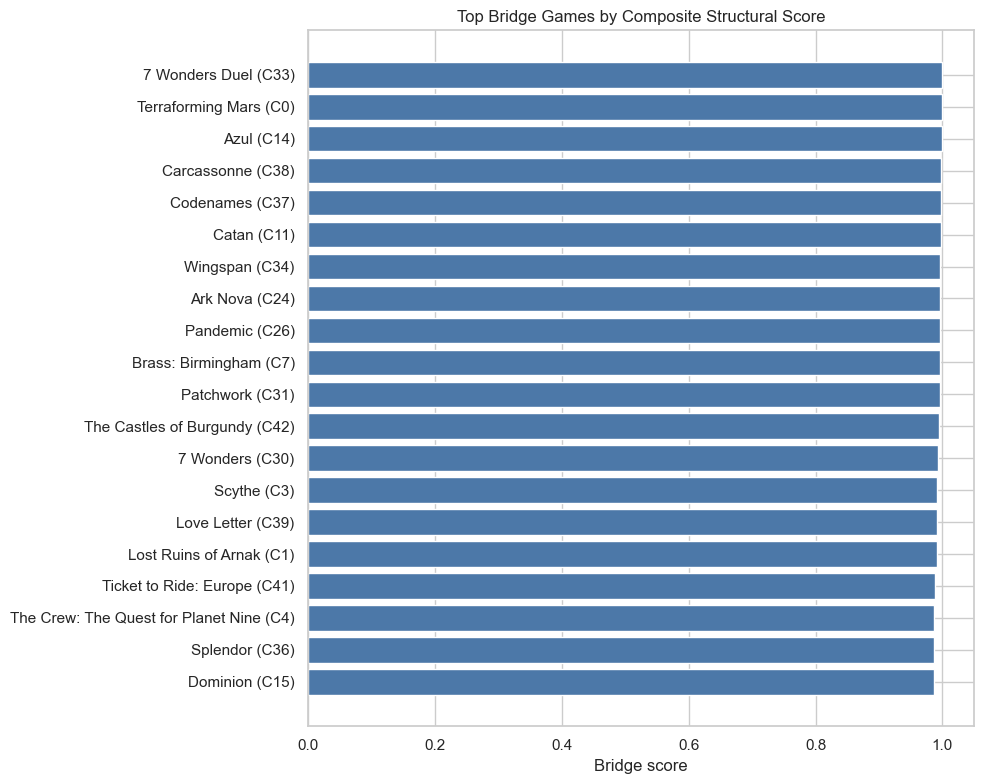

In [4]:
plot_bridge = bridge_table.head(20).copy().sort_values("bridge_score")
plot_bridge["label"] = plot_bridge["name"] + " (C" + plot_bridge["community"].astype(str) + ")"

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_bridge["label"], plot_bridge["bridge_score"], color="#4C78A8")
ax.set_title("Top Bridge Games by Composite Structural Score")
ax.set_xlabel("Bridge score")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIG / "top_bridge_score_games.png", dpi=220, bbox_inches="tight")
plt.show()

## 3. Community condensation interpretation

The condensation graph collapses the 2,500-game network into a 43-community network. Each node is a detected community, and each edge is the total co-ownership backbone weight between two communities.

This answers: which taste communities are behaviorally adjacent?

In [5]:
labels = cond_nodes[["community", "manual_label", "community_type", "size", "internal_weight_share"]].copy()

adjacency = cond_edges.merge(
    labels.rename(columns={
        "community": "community_a", "manual_label": "label_a", "community_type": "type_a",
        "size": "size_a", "internal_weight_share": "internal_share_a",
    }),
    on="community_a", how="left",
).merge(
    labels.rename(columns={
        "community": "community_b", "manual_label": "label_b", "community_type": "type_b",
        "size": "size_b", "internal_weight_share": "internal_share_b",
    }),
    on="community_b", how="left",
)

adjacency["pair_label"] = (
    "C" + adjacency["community_a"].astype(str) + " " + adjacency["label_a"].fillna("unlabeled")
    + "  <->  C" + adjacency["community_b"].astype(str) + " " + adjacency["label_b"].fillna("unlabeled")
)
adjacency["weight_pct"] = adjacency["total_weight"].rank(pct=True)

top_adjacencies = adjacency.sort_values("total_weight", ascending=False)[[
    "community_a", "label_a", "type_a", "community_b", "label_b", "type_b",
    "edge_count", "total_weight", "mean_weight", "pair_label",
]]
top_adjacencies.to_csv(OUT / "top_community_adjacencies.csv", index=False)
top_adjacencies.head(25)

,community_a,label_a,type_a,community_b,label_b,type_b,edge_count,total_weight,mean_weight,pair_label
309,8,Medium worker-placement euros,taste_specialist,10,BGG Golden Age canon,temporal_canon,4110,1871.719891,0.455406,C8 Medium worker-placement euros <-> C10 BGG Golden Age canon
99,2,Current heavy euro engine builders,taste_specialist,19,Recent releases / new-hotness cluster,temporal_artifact,3475,1777.455243,0.511498,C2 Current heavy euro engine builders <-> C19 Recent releases / new-hotness cluster
342,9,Amerithrash / miniatures / LCG,taste_specialist,10,BGG Golden Age canon,temporal_canon,3956,1637.461790,0.413919,C9 Amerithrash / miniatures / LCG <-> C10 BGG Golden Age canon
389,10,BGG Golden Age canon,temporal_canon,25,Party / family / social deduction,taste_cross_over,3232,1629.422713,0.504153,C10 BGG Golden Age canon <-> C25 Party / family / social deduction
384,10,BGG Golden Age canon,temporal_canon,20,Historical wargames + conflict strategy,taste_specialist,4473,1621.048801,0.362408,C10 BGG Golden Age canon <-> C20 Historical wargames + conflict strategy
473,13,Puzzle / nature tableau builders,taste_cross_over,19,Recent releases / new-hotness cluster,temporal_artifact,3476,1617.493459,0.465332,C13 Puzzle / nature tableau builders <-> C19 Recent releases / new-hotness cluster
88,2,Current heavy euro engine builders,taste_specialist,8,Medium worker-placement euros,taste_specialist,2759,1609.251763,0.583274,C2 Current heavy euro engine builders <-> C8 Medium worker-placement euros
344,9,Amerithrash / miniatures / LCG,taste_specialist,12,Dungeon crawl / cooperative campaign adventure,taste_specialist,3743,1540.922218,0.411681,C9 Amerithrash / miniatures / LCG <-> C12 Dungeon crawl / cooperative campaign adventure
357,9,Amerithrash / miniatures / LCG,taste_specialist,25,Party / family / social deduction,taste_cross_over,3120,1441.750288,0.462099,C9 Amerithrash / miniatures / LCG <-> C25 Party / family / social deduction
444,12,Dungeon crawl / cooperative campaign adventure,taste_specialist,19,Recent releases / new-hotness cluster,temporal_artifact,2973,1344.188995,0.452132,C12 Dungeon crawl / cooperative campaign adventure <-> C19 Recent releases / new-hotness cluster


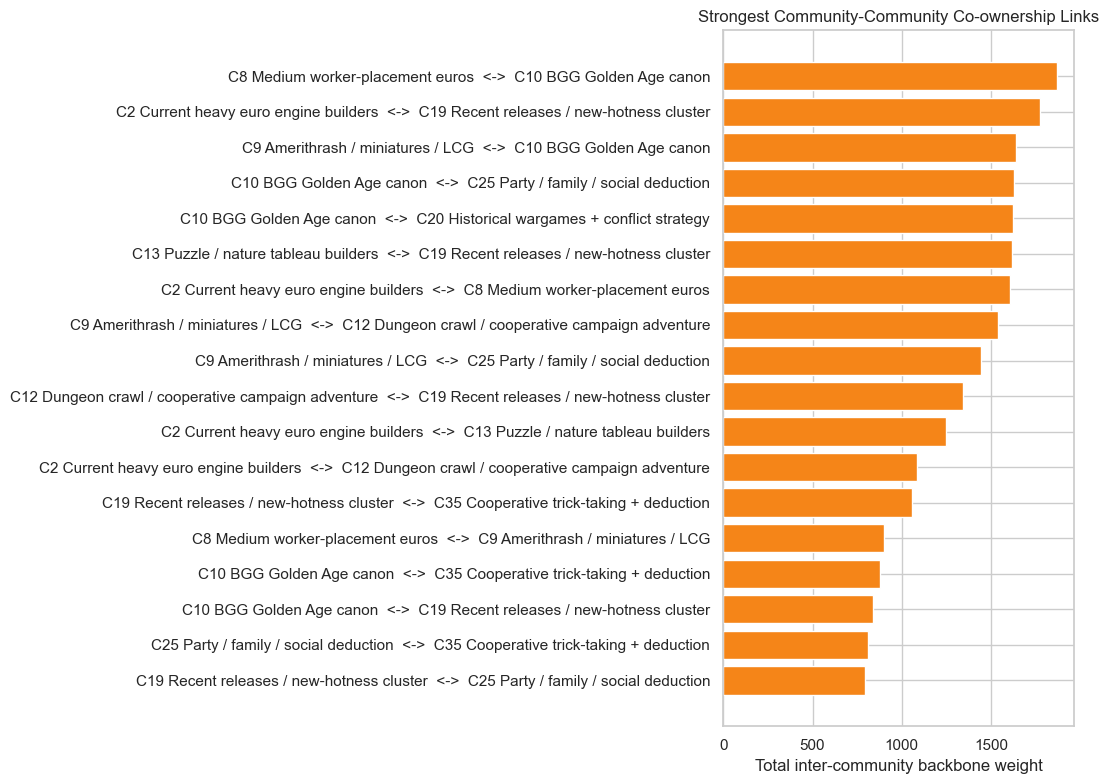

In [6]:
plot_adj = top_adjacencies.head(18).copy().sort_values("total_weight")

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(plot_adj["pair_label"], plot_adj["total_weight"], color="#F58518")
ax.set_title("Strongest Community-Community Co-ownership Links")
ax.set_xlabel("Total inter-community backbone weight")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIG / "top_community_adjacencies.png", dpi=220, bbox_inches="tight")
plt.show()

## 4. Community centrality in the condensation graph

The condensation node table can also identify communities that are broadly connected to other communities. These are not necessarily the most internally coherent communities. They are the communities most exposed to the rest of the hobby network.

In [7]:
community_exposure = cond_nodes.copy()
community_exposure["external_weight_share"] = 1.0 - community_exposure["internal_weight_share"]
community_exposure["external_weight_rank"] = community_exposure["external_weight"].rank(ascending=False, method="min")
community_exposure["internal_share_rank"] = community_exposure["internal_weight_share"].rank(ascending=False, method="min")

community_exposure_table = community_exposure.sort_values("external_weight", ascending=False)[[
    "community", "manual_label", "community_type", "size", "median_year", "external_weight", "internal_weight_share", "external_weight_share"
]]
community_exposure_table.to_csv(OUT / "community_exposure_table.csv", index=False)
community_exposure_table.head(15)

,community,manual_label,community_type,size,median_year,external_weight,internal_weight_share,external_weight_share
10,10,BGG Golden Age canon,temporal_canon,338,2004.0,16677.336112,0.194591,0.805409
19,19,Recent releases / new-hotness cluster,temporal_artifact,231,2023.0,14094.791377,0.129428,0.870572
2,2,Current heavy euro engine builders,taste_specialist,207,2022.0,13792.477680,0.179275,0.820725
9,9,Amerithrash / miniatures / LCG,taste_specialist,251,2012.0,13001.783436,0.145385,0.854615
25,25,Party / family / social deduction,taste_cross_over,177,2014.0,12705.959835,0.088994,0.911006
12,12,Dungeon crawl / cooperative campaign adventure,taste_specialist,231,2021.0,12185.530596,0.137443,0.862557
8,8,Medium worker-placement euros,taste_specialist,166,2014.0,11152.378145,0.104425,0.895575
13,13,Puzzle / nature tableau builders,taste_cross_over,168,2021.0,10913.125962,0.080193,0.919807
35,35,Cooperative trick-taking + deduction,taste_cross_over,100,2018.0,7911.197120,0.056709,0.943291
20,20,Historical wargames + conflict strategy,taste_specialist,198,2012.0,7435.753892,0.189646,0.810354


## 5. Core/periphery summaries for major communities

For each major community, core games are ranked by internal strength. Boundary games are ranked by external strength and low internal strength share.

This turns community labels into a more precise statement: each community has a core, but some games sit at its boundary and connect outward.

In [8]:
major_communities = [10, 20, 2, 8, 9, 12, 25, 13, 35, 19]

summary_rows = []
long_rows = []

for comm in major_communities:
    sub = core[core["community"] == comm].copy()
    if sub.empty:
        continue
    label = sub["manual_label"].dropna().iloc[0] if sub["manual_label"].notna().any() else f"Community {comm}"
    ctype = sub["community_type"].dropna().iloc[0] if sub["community_type"].notna().any() else "unknown"
    core_games = sub.sort_values("internal_strength", ascending=False).head(5)
    boundary_games = sub.assign(external_share=1.0 - sub["internal_strength_share"]).sort_values(
        ["external_strength", "external_share"], ascending=False
    ).head(5)

    summary_rows.append({
        "community": comm,
        "label": label,
        "type": ctype,
        "size": len(sub),
        "core_games": "; ".join(core_games["name"].tolist()),
        "boundary_games": "; ".join(boundary_games["name"].tolist()),
    })

    for role, table in [("core", core_games), ("boundary", boundary_games)]:
        for row in table.itertuples(index=False):
            long_rows.append({
                "community": comm,
                "label": label,
                "role": role,
                "game": row.name,
                "overall_rank": row.overall_rank,
                "internal_strength": row.internal_strength,
                "external_strength": row.external_strength,
                "internal_strength_share": row.internal_strength_share,
                "betweenness_approx": row.betweenness_approx,
            })

community_core_boundary_summary = pd.DataFrame(summary_rows)
community_core_boundary_long = pd.DataFrame(long_rows)
community_core_boundary_summary.to_csv(OUT / "community_core_boundary_summary.csv", index=False)
community_core_boundary_long.to_csv(OUT / "community_core_boundary_long.csv", index=False)
community_core_boundary_summary

,community,label,type,size,core_games,boundary_games
0,10,BGG Golden Age canon,temporal_canon,338,Puerto Rico; Power Grid; Bohnanza; Agricola; Lost Cities,Power Grid; Bohnanza; Lost Cities; Puerto Rico; Agricola
1,20,Historical wargames + conflict strategy,taste_specialist,198,Twilight Struggle; Brass: Lancashire; War of the Ring: Second Edition; Food Chain Magnate; Pax Pamir: Second Edition,Twilight Struggle; Brass: Lancashire; War of the Ring: Second Edition; Food Chain Magnate; Pax Pamir: Second Edition
2,2,Current heavy euro engine builders,taste_specialist,207,Underwater Cities; The White Castle; Gaia Project; Barrage; A Feast for Odin,A Feast for Odin; Gaia Project; The White Castle; Architects of the West Kingdom; SETI: Search for Extraterrestrial ...
3,8,Medium worker-placement euros,taste_specialist,166,Tzolk'in: The Mayan Calendar; Orléans; Le Havre; Great Western Trail; Terra Mystica,Tzolk'in: The Mayan Calendar; Orléans; Great Western Trail; Terra Mystica; Caverna: The Cave Farmers
4,9,Amerithrash / miniatures / LCG,taste_specialist,251,King of Tokyo; Star Wars: Rebellion; Lords of Waterdeep; Small World; Blood Rage,King of Tokyo; Blood Rage; Small World; Lords of Waterdeep; Star Wars: Rebellion
5,12,Dungeon crawl / cooperative campaign adventure,taste_specialist,231,Spirit Island; Gloomhaven: Jaws of the Lion; Gloomhaven; Arkham Horror: The Card Game; Robinson Crusoe: Adventures o...,Spirit Island; Gloomhaven; Gloomhaven: Jaws of the Lion; Robinson Crusoe: Adventures on the Cursed Island; Arkham Ho...
6,25,Party / family / social deduction,taste_cross_over,177,Dixit; Hanabi; Sushi Go!; Coup; Takenoko,Hanabi; Dixit; Sushi Go!; Sushi Go Party!; Coup
7,13,Puzzle / nature tableau builders,taste_cross_over,168,Cascadia; Sagrada; Cartographers; Welcome To...; Earth,Cascadia; Sagrada; Cartographers; Welcome To...; Earth
8,35,Cooperative trick-taking + deduction,taste_cross_over,100,The Mind; The Crew: Mission Deep Sea; The Quest for El Dorado; Decrypto; Arboretum,The Crew: Mission Deep Sea; The Quest for El Dorado; The Mind; Codenames: Duet; Arboretum
9,19,Recent releases / new-hotness cluster,temporal_artifact,231,SCOUT; Sky Team; Sea Salt & Paper; Flip 7; Harmonies,SCOUT; Sky Team; Heat: Pedal to the Metal; Flip 7; Sea Salt & Paper


In [9]:
display_cols = [
    "community", "label", "role", "game", "overall_rank",
    "internal_strength", "external_strength", "internal_strength_share", "betweenness_approx",
]
community_core_boundary_long[display_cols].head(100)

,community,label,role,game,overall_rank,internal_strength,external_strength,internal_strength_share,betweenness_approx
0,10,BGG Golden Age canon,core,Puerto Rico,55,225.929209,754.659383,0.230402,0.025044
1,10,BGG Golden Age canon,core,Power Grid,74,224.832931,1012.908975,0.181648,0.021527
2,10,BGG Golden Age canon,core,Bohnanza,544,208.639497,834.875106,0.199939,0.002272
3,10,BGG Golden Age canon,core,Agricola,64,202.378484,718.042136,0.219876,0.002621
4,10,BGG Golden Age canon,core,Lost Cities,344,184.528450,790.501419,0.189254,0.000934
...,...,...,...,...,...,...,...,...,...
95,19,Recent releases / new-hotness cluster,boundary,SCOUT,105,174.888224,938.197943,0.157120,0.007008
96,19,Recent releases / new-hotness cluster,boundary,Sky Team,33,167.855900,835.097363,0.167362,0.001938
97,19,Recent releases / new-hotness cluster,boundary,Heat: Pedal to the Metal,47,145.446146,801.385477,0.153614,0.000400
98,19,Recent releases / new-hotness cluster,boundary,Flip 7,522,156.531488,621.446848,0.201203,0.000710


## 6. One-page evidence table

This final table collects the most compact numerical evidence for the poster/report.

In [10]:
topology_row = topology.iloc[0]
metadata_lift = metadata_similarity[metadata_similarity["sample"] == "observed_over_random_lift"].iloc[0]

evidence = pd.DataFrame([
    {"claim": "Validated graph size", "evidence": f"{int(topology_row['nodes']):,} games and {int(topology_row['edges']):,} backbone edges"},
    {"claim": "Graph is globally connected", "evidence": f"{int(topology_row['components'])} component; {int(topology_row['isolates'])} isolates"},
    {"claim": "Local clustering is high", "evidence": f"Average clustering {topology_row['average_clustering_unweighted']:.3f} vs random expectation {topology_row['er_expected_clustering_same_density']:.3f}"},
    {"claim": "Behavior partly aligns with mechanics", "evidence": f"Observed mechanic Jaccard is {metadata_lift['mean_mechanic_jaccard']:.2f}x random-pair baseline"},
    {"claim": "Behavior partly aligns with categories", "evidence": f"Observed category Jaccard is {metadata_lift['mean_category_jaccard']:.2f}x random-pair baseline"},
    {"claim": "Bridge games can be formalized", "evidence": f"Top bridge-score examples: {', '.join(bridge_table.head(6)['name'].tolist())}"},
    {"claim": "Community adjacency is measurable", "evidence": f"Strongest community-community link: {top_adjacencies.iloc[0]['label_a']} <-> {top_adjacencies.iloc[0]['label_b']}"},
])

evidence.to_csv(OUT / "poster_evidence_table.csv", index=False)
evidence

,claim,evidence
0,Validated graph size,"2,500 games and 214,379 backbone edges"
1,Graph is globally connected,1 component; 0 isolates
2,Local clustering is high,Average clustering 0.783 vs random expectation 0.069
3,Behavior partly aligns with mechanics,Observed mechanic Jaccard is 1.40x random-pair baseline
4,Behavior partly aligns with categories,Observed category Jaccard is 1.67x random-pair baseline
5,Bridge games can be formalized,"Top bridge-score examples: 7 Wonders Duel, Terraforming Mars, Azul, Carcassonne, Codenames, Catan"
6,Community adjacency is measurable,Strongest community-community link: Medium worker-placement euros <-> BGG Golden Age canon


## 7. Export summary

Generated poster-ready outputs:

- `bridge_score_table.csv`
- `top_community_adjacencies.csv`
- `community_exposure_table.csv`
- `community_core_boundary_summary.csv`
- `community_core_boundary_long.csv`
- `poster_evidence_table.csv`
- `top_bridge_score_games.png`
- `top_community_adjacencies.png`

These outputs are meant to be interpreted alongside the validated community detection results, not as a replacement for them.